# Linear Regressor Model

In [10]:
import numpy as np  # type: ignore
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


ruta = r'C:\Users\jthow\iCloudDrive\Documents\3_Maestria_Estadistica_UNINORTE\3_Tercer_Semestre\Machine_Learning\tornados.csv.zip'  
df = pd.read_csv(ruta)  
df['loss'] = df['loss'].replace(0, pd.NA)
df['loss'] = df['loss'].interpolate(method='linear')
df['mag'] = df['mag'].fillna(df['mag'].mean())
df.isnull().sum()

om              0
yr              0
mo              0
dy              0
date            0
time            0
tz              0
datetime_utc    0
st              0
stf             0
mag             0
inj             0
fat             0
loss            0
slat            0
slon            0
elat            0
elon            0
len             0
wid             0
ns              0
sn              0
f1              0
f2              0
f3              0
f4              0
fc              0
dtype: int64

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Definir X y y (asegúrate de que ya tienes estas variables previamente definidas)
X = df[['mag', 'slat', 'slon', 'elat', 'elon', 'len', 'wid','f1', 'f2', 'f3', 'f4','loss']]
y = df['inj']

# Dividir los datos en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y ajustar el modelo de regresión lineal
lr = LinearRegression().fit(X_train, y_train)

# Mostrar los coeficientes y el intercepto del modelo
print("Coeficientes del modelo:", lr.coef_)
print("Intercepto del modelo:", lr.intercept_)

# Hacer predicciones con el modelo en el conjunto de prueba
y_pred = lr.predict(X_test)

# Evaluar el modelo con la puntuación R^2 (coeficiente de determinación)
r2_score = lr.score(X_test, y_test)
print(f"Puntuación R^2 en el conjunto de prueba: {r2_score}")


Coeficientes del modelo: [ 2.10234115e+00 -3.67444189e-02  8.65045714e-04  8.92198545e-03
  1.16704449e-02  2.82022808e-01  3.32650294e-03 -6.83065524e-04
 -7.11357319e-03  1.13180648e-02 -2.35729609e-03  2.91271156e-07]
Intercepto del modelo: -0.07505882239354134
Puntuación R^2 en el conjunto de prueba: 0.3305327486926829


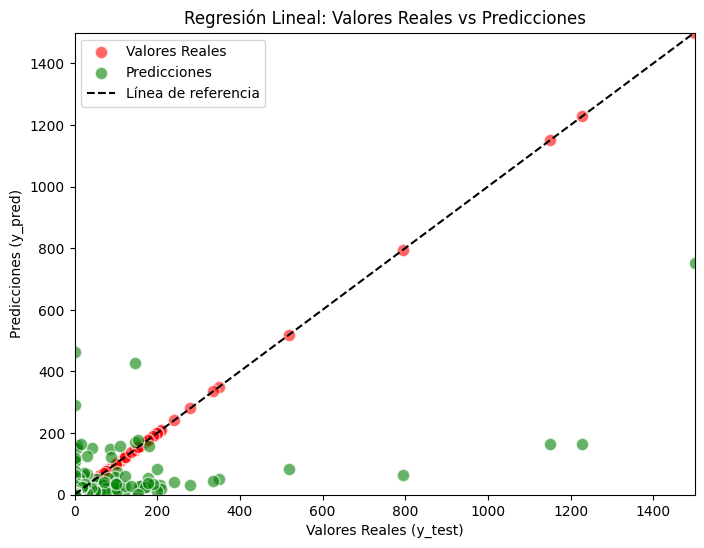

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Asegúrate de que la celda que define y_test y y_pred se haya ejecutado antes de ejecutar esta celda.

# Ajustar el gráfico de dispersión
plt.figure(figsize=(8, 6))

# Graficar los puntos de los valores reales (y_test) en rojo
plt.scatter(y_test, y_test, color='red', alpha=0.6, label="Valores Reales", edgecolors='w', s=80)

# Graficar los puntos de las predicciones (y_pred) en verde
plt.scatter(y_test, y_pred, color='green', alpha=0.6, label="Predicciones", edgecolors='w', s=80)

# Agregar una línea de referencia y = x
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', label="Línea de referencia")

# Ajustar límites de los ejes para que coincidan mejor
plt.xlim([min(y_test) - 0.1, max(y_test) + 0.1])
plt.ylim([min(y_test) - 0.1, max(y_test) + 0.1])

# Etiquetas y título
plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicciones (y_pred)')
plt.title('Regresión Lineal: Valores Reales vs Predicciones')

# Agregar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

## Metricas Linear Regressor

In [ ]:
from gettext import install
# Install the tabulate package
%pip install tabulate

In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from joblib import dump, load

# Cargar los datos (asegúrate de que esta parte sea correcta para tu caso)
# X_train, X_test, y_train, y_test = ...

# Definir el pipeline para el modelo de regresión lineal
pipelines = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
}

# Definir los grids de hiperparámetros para cada modelo
param_grids = {
    'LinearRegression': {}
}

# Realizar GridSearchCV para el modelo
best_models = {}
for model_name, pipeline in pipelines.items():
    if model_name in param_grids:
        grid_search = GridSearchCV(pipeline, param_grids[model_name], cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
        grid_search.fit(X_train, y_train)
        best_models[model_name] = grid_search.best_estimator_
        dump(grid_search, 'grid_lr.joblib')  # Guardar el modelo con el nombre grid_lr.joblib
    else:
        print(f"Warning: Model name '{model_name}' not found in param_grids. Skipping this model.")

# Calcular las métricas para el modelo
metrics = {}
for model_name, model in best_models.items():
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    jb_p_value = jarque_bera(residuals)[1]
    lb_result = acorr_ljungbox(residuals, lags=[10], return_df=False)
    lb_p_value = lb_result['lb_pvalue'].iloc[0]

    metrics[model_name] = {
        "MAPE": f"{mape:.2f}",
        "RMSE": f"{rmse:.2f}",
        "R Cuadrado": f"{r2:.2f}",
        "Ljung-Box p-value": f"{lb_p_value:.2f}",
        "Jarque-Bera p-value": f"{jb_p_value:.2f}"
    }

# Crear un DataFrame combinado para las métricas de todos los modelos
metrics_df = pd.DataFrame(metrics).T

# Redondear los valores a dos decimales
metrics_df = metrics_df.round(2)

# Mostrar la tabla combinada
display(metrics_df)


,Jarque-Bera p-value,Ljung-Box p-value,MAPE,R Cuadrado,RMSE
LinearRegression,0.00,0.93,8950885788248275.00,0.33,18.83
